In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools

In [ ]:
#Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
#custom 1-bit quantization transform function for the MNIST images
class OneBitQuantize:
    def __call__(self, image):
        #quantize the image to 2-bit precision(round to nearest integer 0 or 1)
        quantized_image = torch.round(image)

        return quantized_image

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Resizes to 28x28
    transforms.ToTensor(),  # Converts to tensor,
    OneBitQuantize()
])

test_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    OneBitQuantize()
])



batch_size = 128
#Load MNIST dataset and apply transformations
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform) #60k images
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform) #10k images



#split the training dataset into training and validation datasets
train_size = int(0.83 * len(full_train_dataset)) #50k for training
val_size = len(full_train_dataset) - train_size #10k for validation
train_dataset, _ = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

#create a separate validation dataset with the test transforms
val_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=test_transform)

#subset only the remaining 10% of the data for validation
_, val_dataset = torch.utils.data.random_split(val_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 58.8MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.83MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.16MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [ ]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(train_dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
      img, label = train_dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

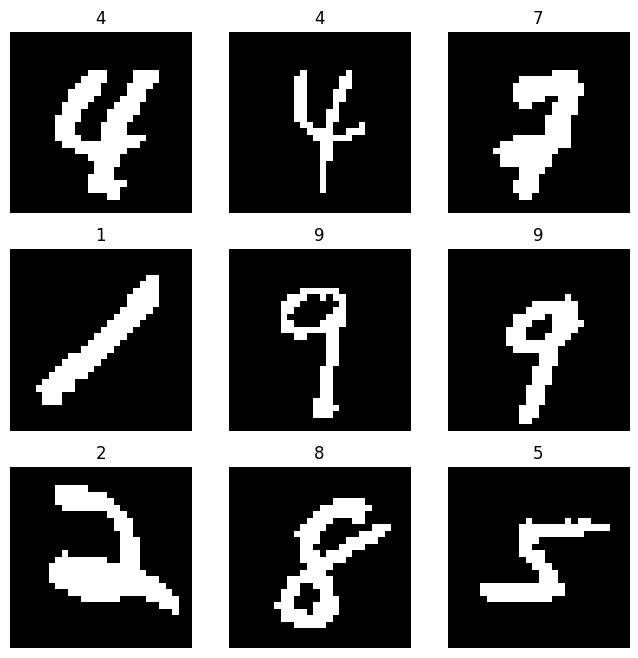

In [ ]:
show_images(train_dataset, 3, 3)

In [ ]:
#this class is a binary activation module that is compatible with forward hooks, expecting a quantized input
class SigmoidBinaryQuant(nn.Module):
  def __init__(self):
    super(SigmoidBinaryQuant, self).__init__()

    self.sigmoid = nn.Sigmoid()

    self.quant = torch.ao.quantization.QuantStub()
    self.dequant = torch.ao.quantization.DeQuantStub()

  def forward(self, x):
    #x = self.dequant(x)
    x = self.sigmoid(x)
    #x = torch.round(x*255)/255
    #x = torch.where(x > 0.5, 1.0, 0.0)
    x = torch.round(x)
    #x = self.quant(x)
    return x


#PIC Conv Layer
class PICConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(PICConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding, bias=False)

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #sum pooling(sum of all kernels = avg * 4)

    self.bias = nn.Parameter(torch.zeros(1, 6, 1, 1)) #a bias term for each feature map(6 feature maps total)

    #use binary sigmoid activation
    self.sigmoid = SigmoidBinaryQuant()


  def forward(self, x):
    self.bias = nn.Parameter(self.bias * 63 / 63) #6 bit bias
    x = self.conv(x)
    x = self.pool(x) * 4
    x = x + self.bias
    x = self.sigmoid(x)
    return x




#EIC Layer 1 Core
class Core(nn.Module):
  def __init__(self, in_features, out_features):
    super(Core, self).__init__()
    self.fc = nn.Linear(in_features, out_features, bias=False)
    self.bias = 0.0
    self.add_fn = torch.ao.nn.quantized.FloatFunctional()
    self.sigmoid = SigmoidBinaryQuant() #1 bit activation

  def forward(self, x):
    x = self.fc(x) * 7 / 7 #3 bit bias of weighted sum
    self.bias = (-0.5 * x.max(dim=1, keepdim=True)[0]) * 7 / 7 #returns tensor of size [batch_size, 1] with max of every batch (each * -0.5), 8-bit
    x = self.add_fn.add(x, self.bias.data)  #simulating subtraction with add
    x = self.sigmoid(x)
    return x



#EIC Layer 1 with 15 cores(4x4 grid minus one core at the lower-right corner)
class EICLayer1(nn.Module):
  def __init__(self):
    super(EICLayer1, self).__init__()

    #create the 15 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=256) for i in range(15)])

  def forward(self, x):
    #split the 1184 inputs into chunks of 256 for each core
    #store the activations in a 4x4 grid
    batch_size = x.size(0)
    activations_grid = torch.empty(batch_size, 4, 4, 256) #for every batch, 4x4 grid of 256 activations
    input_idx = 0
    core_idx = 0


    #loop over the cores, 256 inputs at a time
    for row in range(4):
      for col in range(4):
        if row != 3 or col != 3: #row (3,3) is empty
          if 1184 - input_idx >= 256:
            chunk = x[:, input_idx:input_idx+256]
            input_idx = input_idx + 256

          else: #need to loop back around
            remainder = 256 - (1184 - input_idx)
            chunk = torch.cat((x[:, input_idx:], x[:, :remainder]), dim=1)
            input_idx = remainder

          activations_grid[:, row, col, :] = self.cores[core_idx](chunk) #add the activation to the grid(activations computed for entire batch size at once)
          core_idx = core_idx + 1

    return activations_grid

#EIC Layer 2 with 16 cores(on chip, these cores occupy rows 0 through 3, cols 4 through 7)
class EICLayer2(nn.Module):
  def __init__(self):
    super(EICLayer2, self).__init__()

    #create the 16 cores
    self.cores = nn.ModuleList(
        [Core(in_features=256, out_features=256) for i in range(12)] +
        [Core(in_features=192, out_features=256) for i in range(4)]
    )

  def forward(self, x):
    #input from EICLayer1 of size [batch_size, 4, 4, 256] (4x4 grid of activations from 15 cores, location(3,3) empty)
    batch_size = x.size(0)
    activations_grid = torch.empty(batch_size, 4, 4, 256)
    input_idx = 0
    core_idx = 0


    #loop over the cores, 256(or 192) inputs at a time
    #first three rows take 4 sets of 64 inputs(256 total) of the 4 Layer1 cores on its row
    #last row takes 3 sets of 64 inputs(192 total) of the 3 Layer1 cores on its row
    for row in range(4):
      start_idx = 0

      num_layer1cols = 4
      if row == 3:
        num_layer1cols = 3

      for layer2col in range(4):
        end_idx = start_idx + 64
        chunk = torch.cat([x[:, row, layer1col, start_idx:end_idx] for layer1col in range(num_layer1cols)], dim=1)

        activations_grid[:, row, layer2col, :] = self.cores[core_idx](chunk) #add the activation to the grid(activations computed for entire batch size at once)
        core_idx = core_idx + 1
        start_idx = start_idx + 64

    return activations_grid

#EIC Layer 3 with 16 cores(on chip, these cores occupy rows 4 through 7, cols 4 through 7)
class EICLayer3(nn.Module):
  def __init__(self):
    super(EICLayer3, self).__init__()

    #create the 16 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=64) for i in range(16)])

  def forward(self, x):
    #input from EICLayer2 of size [batch_size, 4, 4, 256] (4x4 grid of activations from 16 cores)
    batch_size = x.size(0)
    activations_grid = torch.empty(batch_size, 4, 4, 64)
    input_idx = 0
    core_idx = 0

    #each core recieves 64 outputs of the 4 Layer2 cores on its column
    #loop over the cores, 256 inputs at a time
    for col in range(4):
      start_idx = 0

      for layer3row in range(4):
        end_idx = start_idx + 64
        chunk = torch.cat([x[:, layer2row, col, start_idx:end_idx] for layer2row in range(4)], dim=1)

        activations_grid[:, layer3row, col, :] = self.cores[core_idx](chunk) #add the activation to the grid(activations computed for entire batch size at once)
        core_idx = core_idx + 1
        start_idx = start_idx + 64

    return activations_grid

#EIC Layer 4 with 4 cores(on chip, these cores occupy rows 4 through 7, col 3)
class EICLayer4(nn.Module):
  def __init__(self):
    super(EICLayer4, self).__init__()

    #create the 4 cores
    self.cores = nn.ModuleList([Core(in_features=256, out_features=64) for i in range(4)])

  def forward(self, x):
    #input from EICLayer2 of size [batch_size, 4, 4, 64] (4x4 grid of activations from 16 cores)
    batch_size = x.size(0)
    activations_grid = torch.empty(batch_size, 4, 1, 64)
    input_idx = 0
    core_idx = 0

    #each core recieves all 64 outputs of the 4 Layer3 cores on its row
    #loop over the cores, 256 inputs at a time
    for row in range(4):
      chunk = torch.cat([x[:, row, layer3col, :] for layer3col in range(4)], dim=1)

      activations_grid[:, row, 0, :] = self.cores[core_idx](chunk) #add the activation to the grid(activations computed for entire batch size at once)
      core_idx = core_idx + 1

    return activations_grid




#overall architecture
class Part8_ci(nn.Module):
  def __init__(self):
    super(Part8_ci, self).__init__()
    self.piclayer1 = PICConvLayer(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1)
    self.flatten = nn.Flatten()
    self.eiclayer1 = EICLayer1()
    self.eiclayer2 = EICLayer2()
    self.eiclayer3 = EICLayer3()
    self.eiclayer4 = EICLayer4()
    self.output = nn.Linear(256, 10) #the output layer on the chip is is the core at location (3,3)
    #self.softmax = QuantizedSoftmax()
    self.softmax = nn.Softmax(dim=1)

    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    x = self.quant(x)
    x = self.piclayer1(x)
    x = self.flatten(x)
    #pad the inputs to 1184 activations(divisble by 16)
    batch_size = x.size(0)
    x = torch.cat((x, torch.zeros(batch_size, 8)), dim=1)
    x = self.eiclayer1(x)
    x = self.eiclayer2(x)
    x = self.eiclayer3(x)
    x = self.eiclayer4(x)
    x = self.flatten(x)
    x = self.output(x)
    x = self.dequant(x)
    x = self.softmax(x)
    #x = torch.round(x * 255) / 255
    #x = x / x.sum(dim=-1, keepdim=True)
    return x

In [ ]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd_qat(model, train_loader, val_loader, optimizer, scheduler, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  print(device)
  best_val_accuracy = 0

  early_stop_threshold = 5
  best_val_loss = 100.0 #absurd loss
  epochs_without_improvement = 0

  #lists to store loss and accuracy values
  train_losses = []
  val_losses = []
  train_accuracies = []
  val_accuracies = []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(train_loader, 0):

      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      inputs = inputs.to(device)
      labels = labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights before the optimizer steps.
      # with torch.no_grad():  #disable gradient tracking
      #   for param in model.parameters():
      #     #project all weights to nonnegative values
      #     param.data = torch.clamp(param.data, min=0.00001)


      #     # #quantize all weights
      #     # #exclude conv and pooling layers from 8-bit quantization
      #     # if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
      #     #   #param.data = weight_quantizer(param.data)
      #     #   param.data = torch.round(param.data * 256) / 256


      # any_negative = False
      # #check if weights are nonnegative
      # for name, param in model.named_parameters():
      #     if torch.any(param.data < 0):
      #         any_negative = True
      # if any_negative:
      #   print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
        running_loss = 0.0

      correct_train += (predicted == labels).sum().item()
      total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    #validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        #statistics
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    #check for early stopping based on validation loss
    if val_losses[-1] < best_val_loss:
      best_val_loss = val_losses[-1]
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    # If the validation loss starts increasing or is plateauing, stop training
    if epochs_without_improvement > early_stop_threshold:
      print(f"Early stopping at epoch {epoch}")
      break



    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{epochs}, Learning Rate: {optimizer.param_groups[0]['lr']},")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    if (val_accuracy >= best_val_accuracy):
      #save model
      torch.save(model.state_dict(), './pic_qat_part8ci.pth')
      best_val_accuracy = val_accuracy

    #step the scheduler at the end of each epoch (PART 5), for dynamic learning rates
    #scheduler.step()
    #scheduler.step(val_loss)


  print("Training complete")



  #plot losses and accuracies
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(len(train_losses)), train_losses, label='Training Loss')
  plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy')
  plt.plot(range(len(val_accuracies)), val_accuracies, label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

  min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
  print(f"Epoch with the lowest validation loss: {min_val_loss_epoch}")



In [ ]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd_qat_warmup(model, train_loader, val_loader, optimizer, warmup_scheduler, scheduler, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  print(device)
  best_val_accuracy = 0

  early_stop_threshold = 5
  best_val_loss = 100.0 #absurd loss
  epochs_without_improvement = 0

  #lists to store loss and accuracy values
  train_losses = []
  val_losses = []
  train_accuracies = []
  val_accuracies = []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(train_loader, 0):

      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      inputs = inputs.to(device)
      labels = labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights before the optimizer steps.
      # with torch.no_grad():  #disable gradient tracking
      #   for param in model.parameters():
      #     #project all weights to nonnegative values
      #     param.data = torch.clamp(param.data, min=0.00001)


      #     # #quantize all weights
      #     # #exclude conv and pooling layers from 8-bit quantization
      #     # if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
      #     #   #param.data = weight_quantizer(param.data)
      #     #   param.data = torch.round(param.data * 256) / 256


      # any_negative = False
      # #check if weights are nonnegative
      # for name, param in model.named_parameters():
      #     if torch.any(param.data < 0):
      #         any_negative = True
      # if any_negative:
      #   print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
        running_loss = 0.0

      correct_train += (predicted == labels).sum().item()
      total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    #validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        #statistics
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    #check for early stopping based on validation loss
    if val_losses[-1] < best_val_loss:
      best_val_loss = val_losses[-1]
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    # If the validation loss starts increasing or is plateauing, stop training
    if epochs_without_improvement > early_stop_threshold:
      print(f"Early stopping at epoch {epoch}")
      break



    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{epochs}, Learning Rate: {optimizer.param_groups[0]['lr']},")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    if val_accuracy >= best_val_accuracy:
      #save model
      torch.save(model.state_dict(), './pic_qat_part8ci.pth')
      best_val_accuracy = val_accuracy

    #step the scheduler at the end of each epoch (PART 5), for dynamic learning rates
    #scheduler.step()
    #scheduler.step(val_loss)

    if epoch < 20:
      warmup_scheduler.step()
    else:
      scheduler.step()


  print("Training complete")



  #plot losses and accuracies
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(len(train_losses)), train_losses, label='Training Loss')
  plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(len(train_accuracies)), train_accuracies, label='Training Accuracy')
  plt.plot(range(len(val_accuracies)), val_accuracies, label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

  min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
  print(f"Epoch with the lowest validation loss: {min_val_loss_epoch}")



In [ ]:
#hooks used to store activations
def evaluate_model_custom_binary(model, test_loader):
    model.eval()  # Set model to evaluation mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    correct = 0
    total = 0

    activations = []


    def get_activations_hook_fn(module, input, output): #forward hook(function ran in every forward pass)
      activations.append(output.detach().cpu().numpy()) #get the output of the activations and store it, int_repr shows the quantized activations

    activation_hooks = []

    for name, module in model.named_modules():
      if name in ('activation1','activation2'):  #apply hooks on hidden layers
        activation_hooks.append(module.register_forward_hook(get_activations_hook_fn))

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total

    #detach hooks after usage
    for hook in activation_hooks:
      hook.remove()

    #analyze activations from hooks
    if (len(activations) > 0):
      flattened_activations = np.concatenate([activation.flatten() for activation in activations]) #flatten all activations into a list
      np.random.shuffle(flattened_activations)
      activations_samples = flattened_activations[:100]
      print(activations_samples)
      print(len(activations_samples))

    return accuracy

In [ ]:
#model = Chip_Architecture_Step1()
#model_qat = BasicNetwork_NoCNN()
model_qat = Part8_ci()
print(model_qat)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

Part8_ci(
  (piclayer1): PICConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (sigmoid): SigmoidBinaryQuant(
      (sigmoid): Sigmoid()
      (quant): QuantStub()
      (dequant): DeQuantStub()
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (eiclayer1): EICLayer1(
    (cores): ModuleList(
      (0-14): 15 x Core(
        (fc): Linear(in_features=256, out_features=256, bias=False)
        (add_fn): FloatFunctional(
          (activation_post_process): Identity()
        )
        (sigmoid): SigmoidBinaryQuant(
          (sigmoid): Sigmoid()
          (quant): QuantStub()
          (dequant): DeQuantStub()
        )
      )
    )
  )
  (eiclayer2): EICLayer2(
    (cores): ModuleList(
      (0-11): 12 x Core(
        (fc): Linear(in_features=256, out_features=256, bias=False)
        (add_fn): FloatFunctional(
          (activation_post_process): Identity()
        )
 

In [ ]:
model_qat.eval() #model needs to be in eval mode for fusing layers
model_qat.qconfig = torch.ao.quantization.get_default_qconfig('x86')
model_qat_fused = model_qat
#model_fused = torch.ao.quantization.fuse_modules(model,[['conv1', 'flatten', 'fc']]) ---Not sure if necessary
#model_fused = torch.ao.quantization.fuse_modules(model_qat, [['conv', 'bn', 'relu']])

In [ ]:
#prepare the model for quantization training, model needs to be in train
model_qat_prepared = torch.ao.quantization.prepare_qat(model_qat_fused.train())

/usr/local/lib/python3.11/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [ ]:
model_qat_prepared

Part8_ci(
  (piclayer1): PICConvLayer(
    (conv): Conv2d(
      1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
      (weight_fake_quant): PerChannelMinMaxObserver(min_val=tensor([]), max_val=tensor([]))
      (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
    )
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (sigmoid): SigmoidBinaryQuant(
      (sigmoid): Sigmoid(
        (activation_post_process): FixedQParamsFakeQuantize(
          fake_quant_enabled=tensor([1], dtype=torch.uint8), observer_enabled=tensor([1], dtype=torch.uint8), scale=tensor([0.0039]), zero_point=tensor([0], dtype=torch.int32), dtype=torch.quint8, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine
          (activation_post_process): FixedQParamsObserver()
        )
      )
      (quant): QuantStub(
        (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
      )
      (dequant): DeQuantStub()
    )
  )
  (flatten): Flatten(

In [ ]:
#test output shape
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    output = model_qat_prepared(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

Output shape: torch.Size([128, 10])


In [ ]:
def create_sgd_optimizer(model, learning_rate, weight_decay=0.01, momentum=0.8):
  return torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

In [ ]:
def create_adam_optimizer(model, learning_rate):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def train_test_model_qat_warmup(model, learning_rate=0.01, num_epochs=10):
  loss_fn = nn.CrossEntropyLoss()
  print(learning_rate)
  optimizer = create_adam_optimizer(model, learning_rate)
  #optimzer = create_sgd_optimizer(model, learning_rate)

  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 1000, gamma = 1) #essentially no scheduler
  #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 5, 7], gamma=0.1)
  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1) #learning rate annealing (STEP 5), standard step decreases the lr by a scale gamma every number of epochs
  warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.05, end_factor=1, total_iters=20)
  cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs-20) #learning rate annealing(STEP 5), cosine gradually decreases the learning rate more and more, good for sensitive weights
  #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=0.00001) #learning rate annealing (STEP 5), automatically reduces lr when val loss plateaus

  train_model_with_pgd_qat_warmup(model, train_loader, val_loader, optimizer, warmup_scheduler, cosine_scheduler, loss_fn=loss_fn, epochs=num_epochs)


  model.eval()
  #model_int8 = torch.ao.quantization.convert(model)
  #print(model_int8)
  #model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  print("Testing accuracy: " + str(evaluate_model_custom_binary(model, test_loader)))
  return model

In [ ]:
def train_test_model_qat(model, learning_rate=0.01, num_epochs=10):
  loss_fn = nn.CrossEntropyLoss()
  print(learning_rate)
  optimizer = create_adam_optimizer(model, learning_rate)
  #optimzer = create_sgd_optimizer(model, learning_rate)

  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 1000, gamma = 1) #essentially no scheduler
  #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 5, 7], gamma=0.1)
  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1) #learning rate annealing (STEP 5), standard step decreases the lr by a scale gamma every number of epochs
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs-20) #learning rate annealing(STEP 5), cosine gradually decreases the learning rate more and more, good for sensitive weights
  #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=0.00001) #learning rate annealing (STEP 5), automatically reduces lr when val loss plateaus

  train_model_with_pgd_qat(model, train_loader, val_loader, optimizer, scheduler, loss_fn=loss_fn, epochs=num_epochs)


  model.eval()
  #model_int8 = torch.ao.quantization.convert(model)
  #print(model_int8)
  #model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  print("Testing accuracy: " + str(evaluate_model_custom_binary(model, test_loader)))
  return model

In [ ]:
learning_rate = 0.01
num_epochs = 10

0.01
cpu
Epoch 1/10, Learning Rate: 0.01,
Train Loss: 2.2092, Train Accuracy: 25.16%,
Val Loss: 2.1635, Val Accuracy: 30.39%
Epoch 2/10, Learning Rate: 0.01,
Train Loss: 2.1642, Train Accuracy: 29.53%,
Val Loss: 2.1475, Val Accuracy: 31.55%
Epoch 3/10, Learning Rate: 0.01,
Train Loss: 2.1537, Train Accuracy: 30.64%,
Val Loss: 2.1407, Val Accuracy: 32.46%
Epoch 4/10, Learning Rate: 0.01,
Train Loss: 2.1469, Train Accuracy: 31.29%,
Val Loss: 2.1363, Val Accuracy: 32.66%
Epoch 5/10, Learning Rate: 0.01,
Train Loss: 2.1425, Train Accuracy: 31.63%,
Val Loss: 2.1333, Val Accuracy: 33.06%
Epoch 6/10, Learning Rate: 0.01,
Train Loss: 2.1400, Train Accuracy: 32.11%,
Val Loss: 2.1320, Val Accuracy: 33.11%
Epoch 7/10, Learning Rate: 0.01,
Train Loss: 2.1367, Train Accuracy: 32.50%,
Val Loss: 2.1303, Val Accuracy: 33.39%
Epoch 8/10, Learning Rate: 0.01,
Train Loss: 2.1344, Train Accuracy: 32.67%,
Val Loss: 2.1288, Val Accuracy: 33.46%
Epoch 9/10, Learning Rate: 0.01,
Train Loss: 2.1326, Train Accu

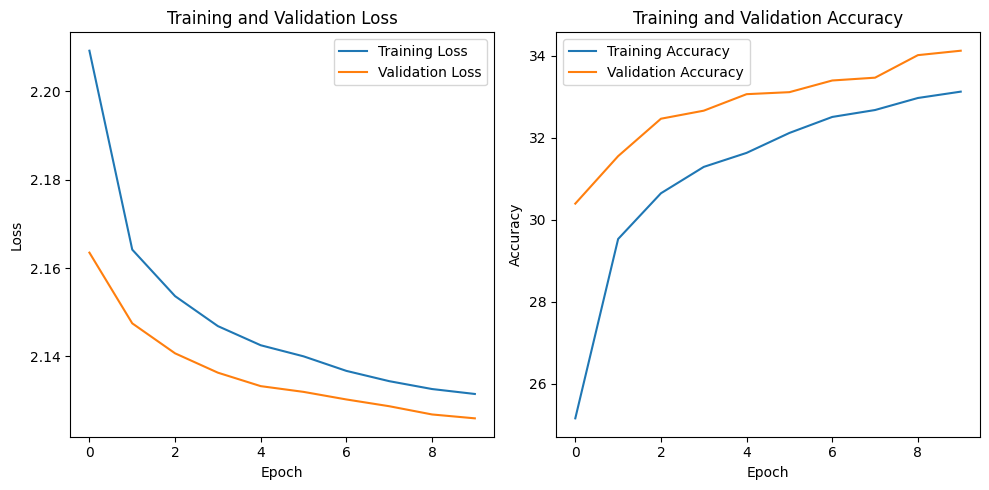

Epoch with the lowest validation loss: 10
Testing accuracy: 27.61


In [ ]:
model_qat_trained = train_test_model_qat(model_qat_prepared, learning_rate, num_epochs)

In [ ]:
model_qat_trained.eval()
model_qat_trained(torch.rand(1,28,28))

tensor([[0.1137, 0.0824, 0.0863, 0.0824, 0.0863, 0.0980, 0.1098, 0.0980, 0.1059,
         0.1451]], grad_fn=<DivBackward0>)

In [ ]:
model_qat_converted = torch.ao.quantization.convert(model_qat_trained)
model_qat_converted.eval()

RuntimeError: Only Tensors created explicitly by the user (graph leaves) support the deepcopy protocol at the moment.  If you were attempting to deepcopy a module, this may be because of a torch.nn.utils.weight_norm usage, see https://github.com/pytorch/pytorch/pull/103001

In [ ]:
model_qat_converted(torch.rand(1,28,28))
evaluate_model_custom_binary(model_qat_converted, test_loader)

In [ ]:
# Run a sample input through the converted model and print dtype at each step
sample_input = torch.randn(1, 784)  # Example input

print(f"Original input dtype: {sample_input.dtype}")

x = model_qat_converted.quant(sample_input)  # Manually quantize input
print(f"After QuantStub: {x.dtype}")  # Should be `torch.quint8` or `torch.qint8`

x = model_qat_converted.layer0_col0(x, model_qat_converted.bias)
print(f"After layer0_col0: {x.dtype}")

x = model_qat_converted.output(x, model_qat_converted.bias)
print(f"After output layer: {x.dtype}")

x = model_qat_converted.dequant(x)  # Manually dequantize before final softmax
print(f"After DeQuantStub: {x.dtype}")

x = model_qat_converted.softmax(x)
print(f"After softmax: {x.dtype}")


In [ ]:
import random
def sample_quantized_weights(model):
  """Samples 100 weights from the quantized model and verifies their type."""
  model_qat = torch.ao.quantization.convert(model)  #ensure model is quantized

  print("Quantized Model Structure:", model_qat)
  model_qat.eval()

  #access the raw quantized weights (without parentheses)
  print("Raw Quantized Weights (fc1) - Quantized (qint8):", model_qat.layer0_col0.core1.fc1.weight())  #this should show quantized weights in their float representation
  print("Raw Quantized Weights (fc1) - Quantized (int8):", model_qat.layer0_col0.core1.fc1.weight().int_repr())  #this should show quantized weights in their integer representations

  #now dequantize and sample
  all_weights = torch.cat([
    model_qat.layer0_col0.core1.fc1.weight().dequantize().view(-1),
    model_qat.layer0_col0.core1.fc2.weight().dequantize().view(-1),
  ]).cpu().detach().numpy()

  all_weights_quant = torch.cat([
    model_qat.layer0_col0.core1.fc1.weight().int_repr().view(-1),
    model_qat.layer0_col0.core1.fc2.weight().int_repr().view(-1),
  ]).cpu().detach().numpy()


  sampled_weights = random.sample(list(all_weights), 100)
  sampled_quant_weights = random.sample(list(all_weights_quant), 100)
  print("Sampled Weights:", sampled_weights)
  print("Sampled Quantized Weights:", sampled_quant_weights)

#example usage:
sample_quantized_weights(model_qat_converted)

NameError: name 'model_qat_converted' is not defined

In [ ]:
#looking at activations

#hook function to store activations
def activation_hook(name):
    def hook(module, input, output):
        sample_activations = output.flatten()[:10].tolist()  # Get first 10 activations
        print(f"Layer: {name} | Sample activations: {sample_activations}")
    return hook

#register hooks for the layers with binary activations
for name, module in model_qat.named_modules():
    if name in ('piclayer1', 'eiclayer1', 'eiclayer2', 'eiclayer3', 'eiclayer4'):  # Only attach hooks to these layers
        module.register_forward_hook(activation_hook(name))


#create a sample input
sample_input = torch.randn(128, 1, 28, 28)  #batch size 1

# Forward pass
with torch.no_grad():
    model_qat(sample_input)


Layer: piclayer1 | Sample activations: [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0]
Layer: eiclayer1 | Sample activations: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Layer: eiclayer2 | Sample activations: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Layer: eiclayer3 | Sample activations: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Layer: eiclayer4 | Sample activations: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]


In [ ]:
import torch
import torch.nn as nn
import torch.ao.quantization as quant

class FakeQuantizedSoftmax(nn.Module):
    def __init__(self, num_bits=8):
        super(FakeQuantizedSoftmax, self).__init__()
        self.num_bits = num_bits
        self.scale = 2**num_bits - 1  # Scale factor for 8-bit quantization
        self.eps = 1e-6  # To avoid log(0) in backward pass

    def forward(self, x):
        softmax_out = torch.softmax(x, dim=-1)  # Compute softmax
        print(softmax_out)
        quantized = torch.round(softmax_out * self.scale) / self.scale  # Simulate 8-bit quantization
        return quantized

# Example usage
x = torch.randn(3, 3)  # Random logits
softmax_q = FakeQuantizedSoftmax()
output = softmax_q(x)
print(output)

tensor([[0.4839, 0.1534, 0.3627],
        [0.2151, 0.4883, 0.2965],
        [0.8532, 0.0702, 0.0766]])
tensor([[0.4824, 0.1529, 0.3608],
        [0.2157, 0.4902, 0.2980],
        [0.8549, 0.0706, 0.0784]])


In [ ]:
x = torch.randn(3, 3)
softmax_dq = torch.softmax(x,dim=-1)
print(softmax_dq)
softmax_q = torch.round(softmax_dq * 3) / 3.0
print(softmax_q)

tensor([[0.6822, 0.2203, 0.0975],
        [0.0588, 0.8230, 0.1182],
        [0.2968, 0.6070, 0.0962]])
tensor([[0.6667, 0.3333, 0.0000],
        [0.0000, 0.6667, 0.0000],
        [0.3333, 0.6667, 0.0000]])


In [ ]:
x = torch.rand(1, 28, 28)
print(model_qat(x))
print(model_qat_trained(x))

tensor([[0.0978, 0.1027, 0.1007, 0.0951, 0.1085, 0.0875, 0.0978, 0.0956, 0.1088,
         0.1054]], grad_fn=<DivBackward0>)


NameError: name 'model_qat_trained' is not defined